# Circuit visualization (`circuit_viz.py`)

Rough pictures of the tapped circuits for sanity checks and figures:

- **Small tasks** (one target wire, k relevant inputs): `draw_circuit(..., highlight=wire)` shows the backward light cone, `compact=True` strips everything else, and `plot_function` shows the target's truth table + Walsh spectrum.
- **Rich tasks** (many wires tapped at many depths): `draw_circuit(..., order="depth")` shows the whole staircase, and `plot_summary` gives the tap-depth histogram, support size vs depth, sensitivity vs depth and the output × input influence matrix.
- **Tree tasks**: `draw_tree` with tapped nodes colored by supervision gap.

All plotting functions return the axes/figure, so `fig.savefig("figs/...")` works for figures.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import circuit_viz as cv
from random_circuit import sample_circuit
from tree_circuit import sample_tree_circuit

## Small circuits

The `tiny_circuit.ipynb` task: 5 wires, depth 3, seed 5, target wire 0. `show_tables=True` prints each gate's truth table (images of inputs 0..7, top wire of the gate = most significant bit). Dots on a gate are its three wires, the diamond is the target's tap, and circles are other wires' taps, colored by depth. Dotted grey spans are wires after they freeze.

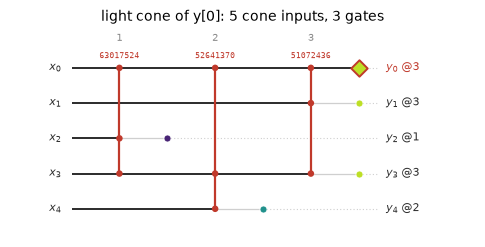

In [2]:
tiny = sample_circuit(np.random.default_rng(5), 5, 3)
cv.draw_circuit(tiny, highlight=0, show_tables=True);

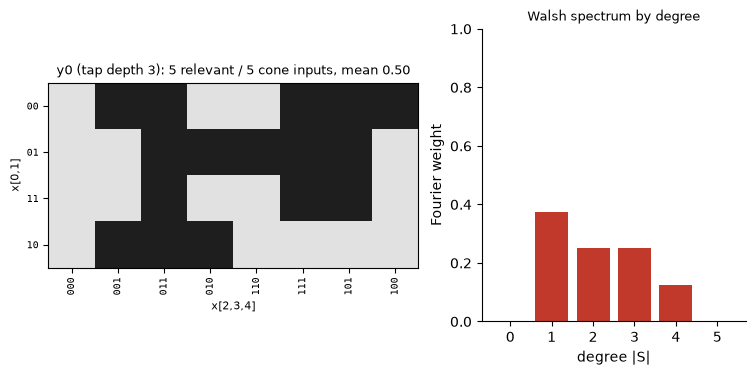

In [3]:
cv.plot_function(tiny, 0);

The `single_epoch14.ipynb` task: 14 wires, depth 8, seed 4, target wire 1. At this depth the light cone already covers every input, and the Walsh weight sits at mid degrees, the way a random function's does.

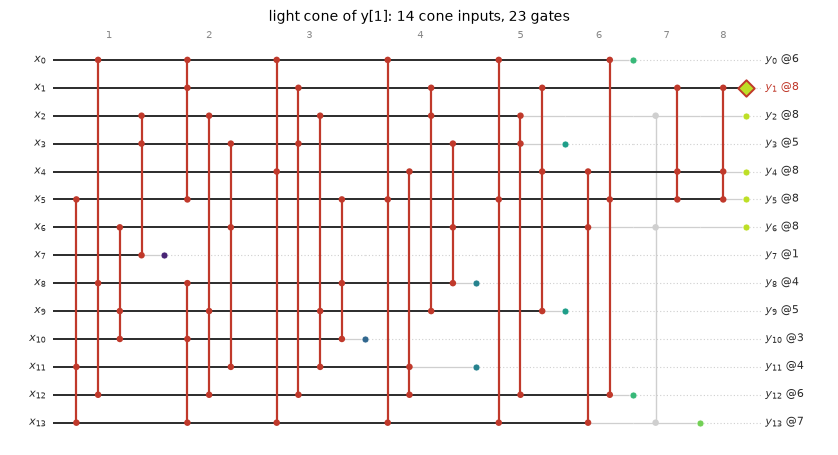

In [4]:
c14 = sample_circuit(np.random.default_rng(4), 14, 8)
cv.draw_circuit(c14, highlight=1);

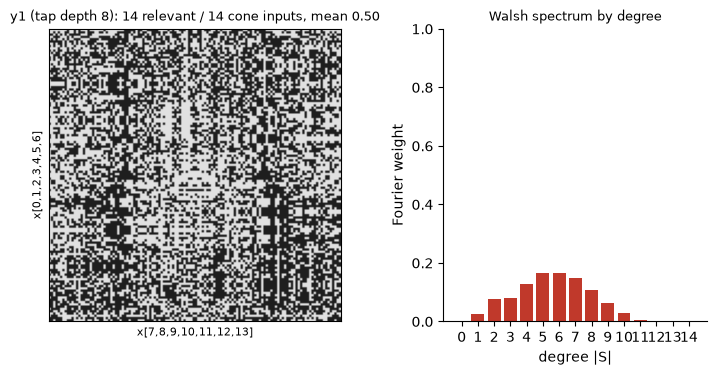

In [5]:
cv.plot_function(c14, 1);

## Rich circuits

The `scale100.ipynb` task: 100 wires, depth 8, uniform tap depths. `order="depth"` puts the deepest taps on top, so the frozen wires form a staircase.

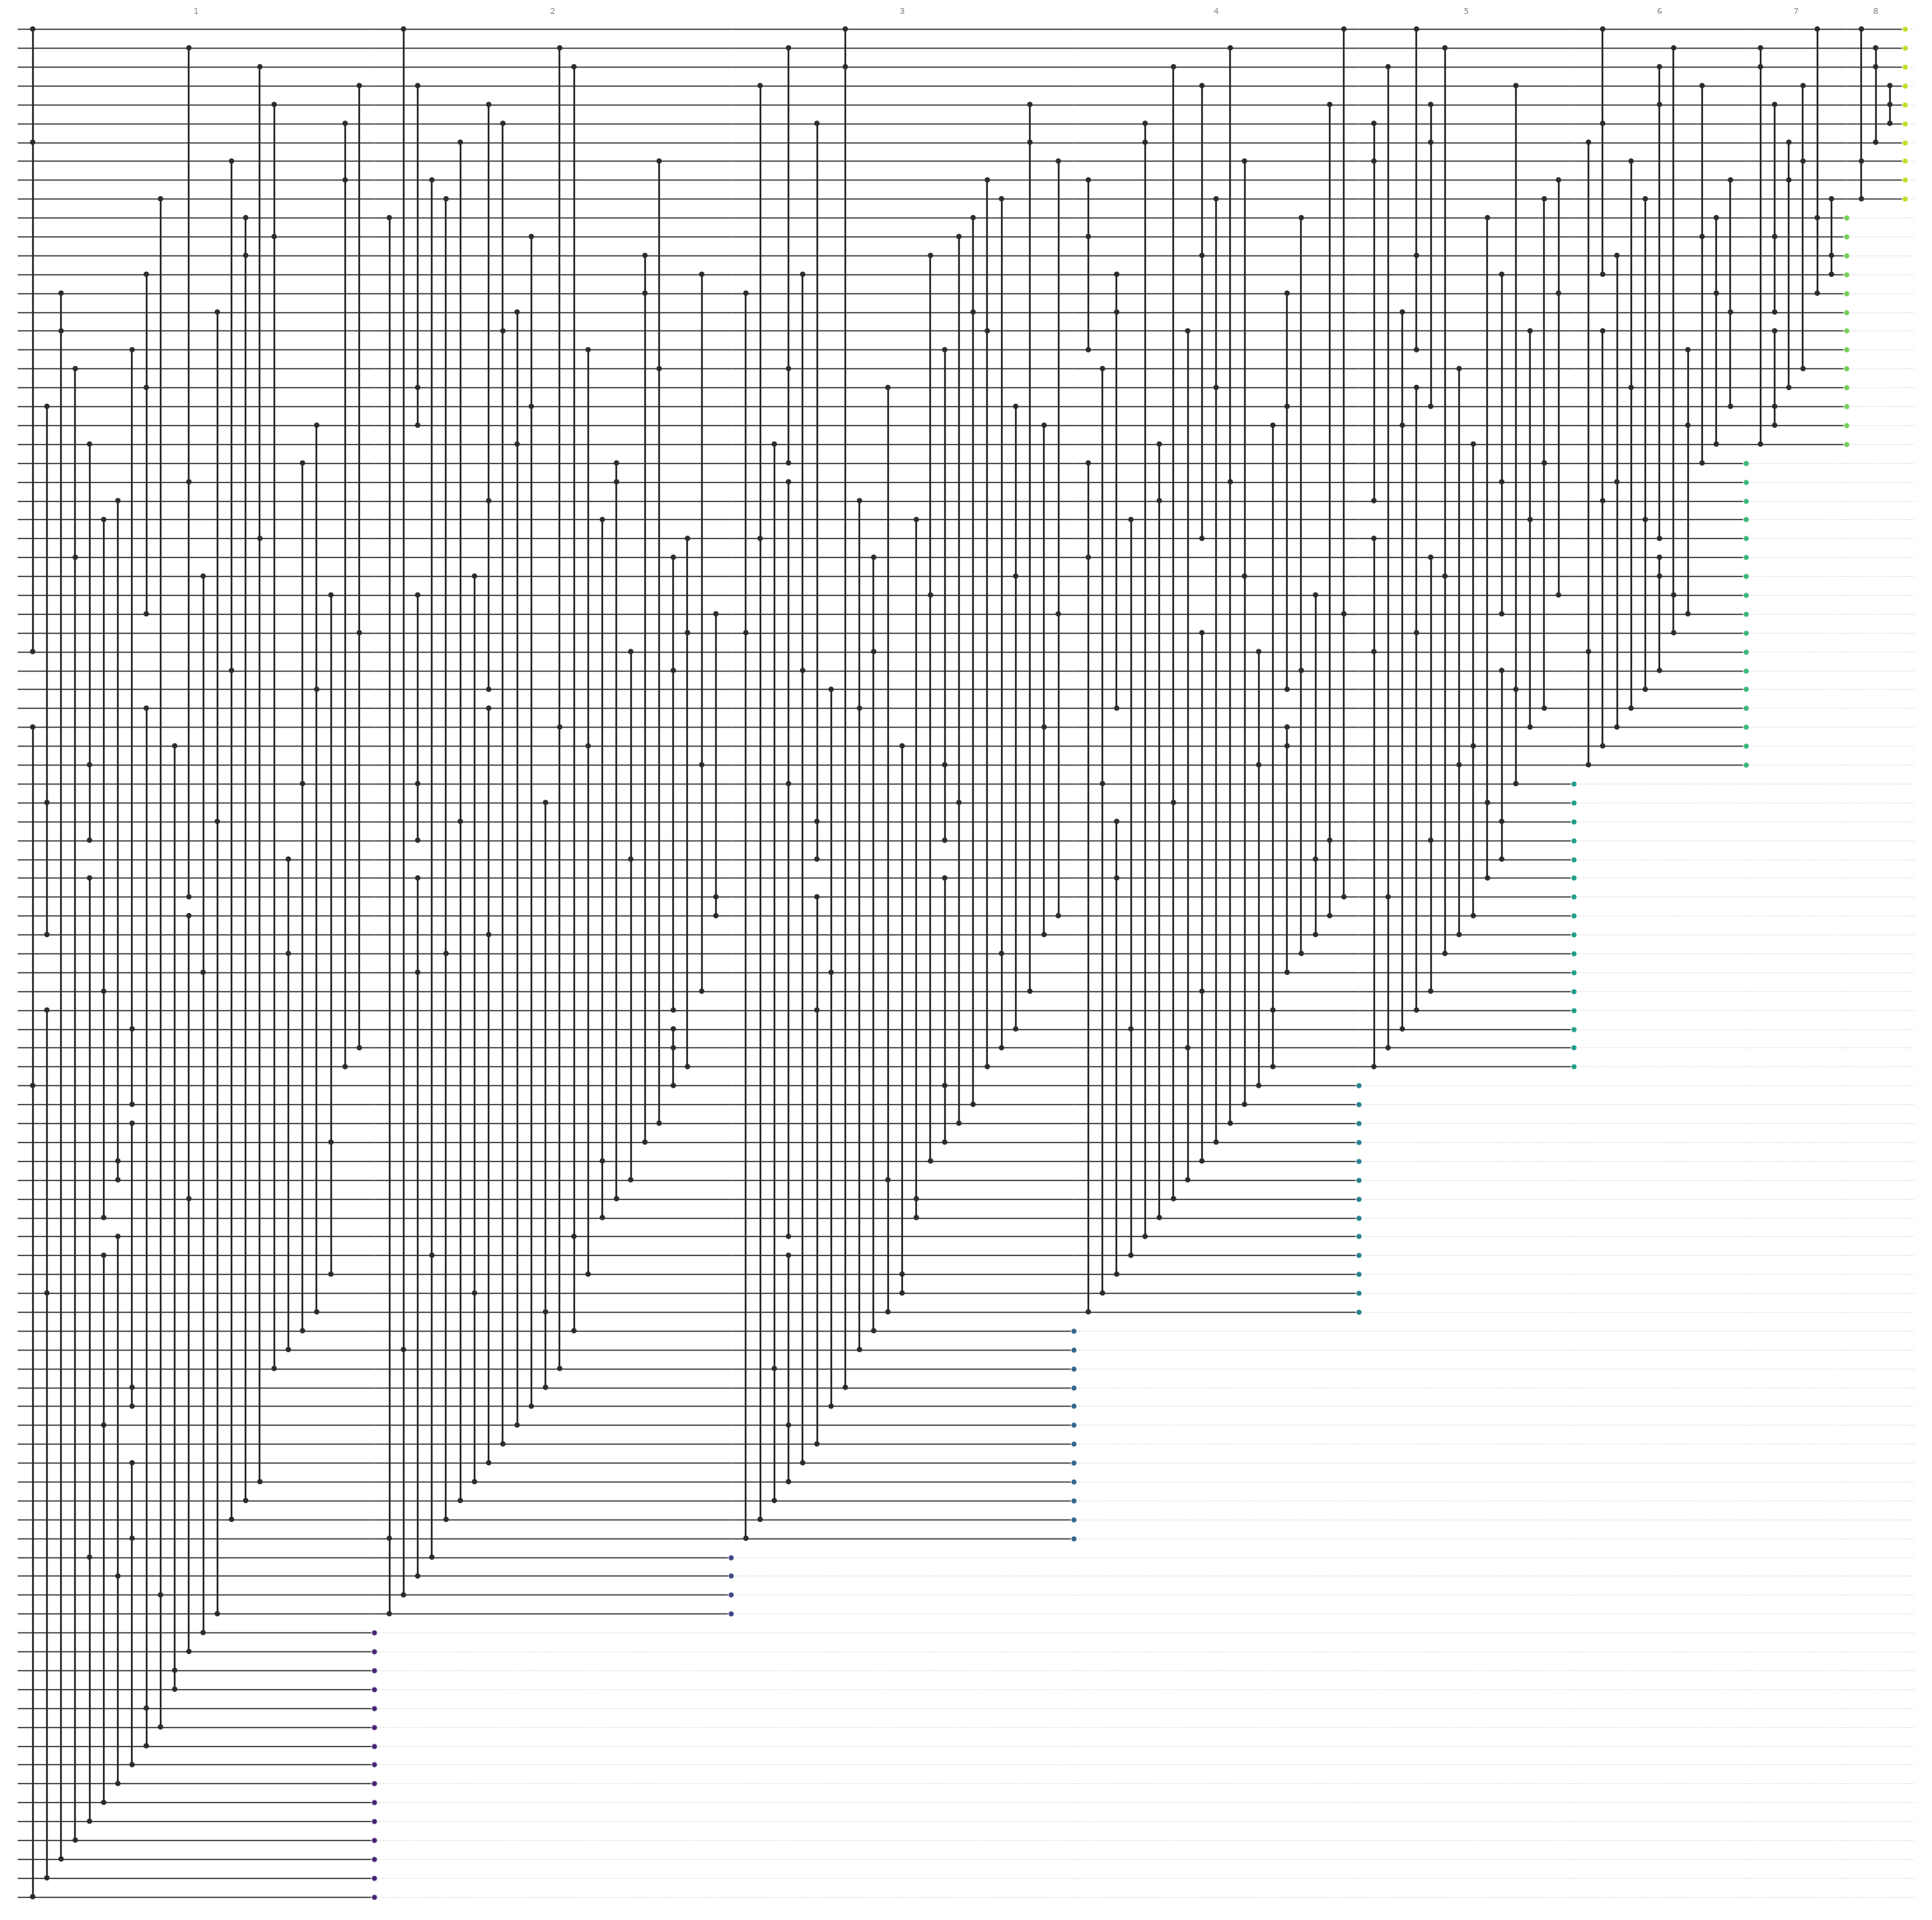

In [6]:
c100 = sample_circuit(np.random.default_rng(0), 100, 8)
cv.draw_circuit(c100, order="depth");

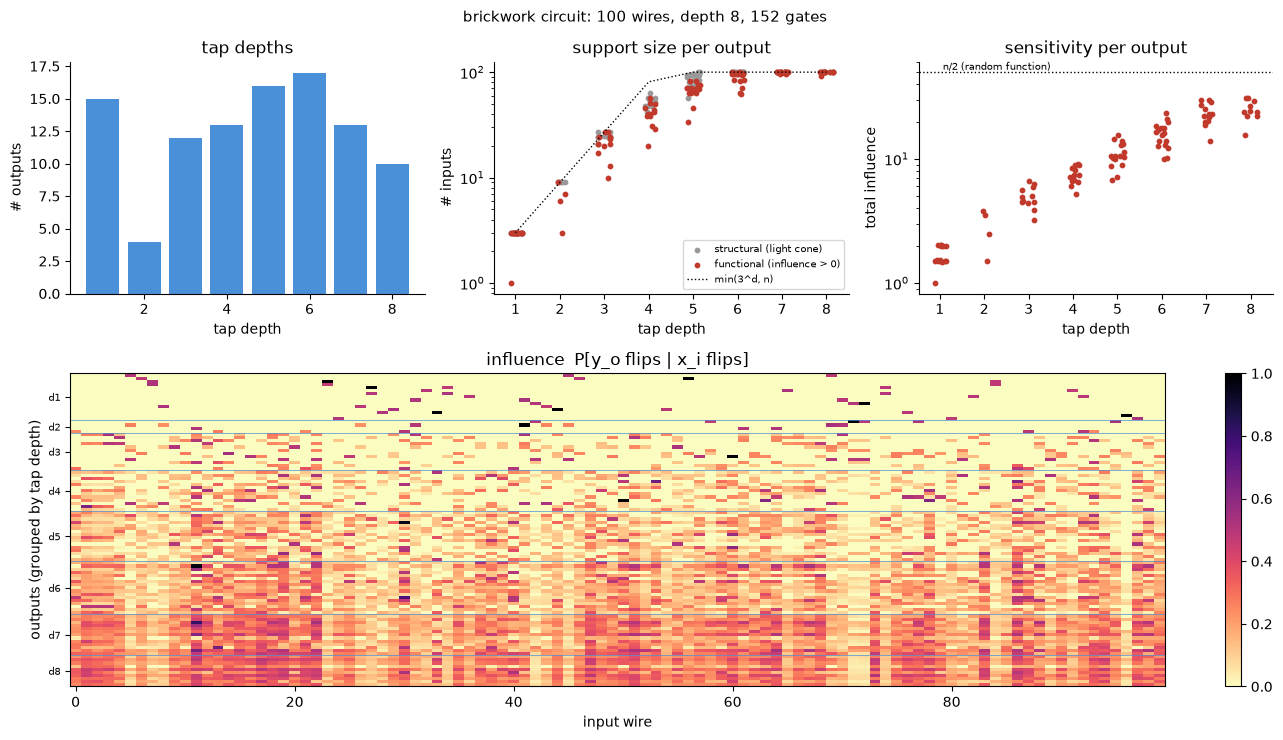

In [7]:
cv.plot_summary(c100);

Any shallow output of a rich circuit is itself a small task. `compact=True` keeps only the wires and gates in its light cone and draws the "k inputs → 1 output" picture:

wire 8: tap depth 2, cone inputs [ 8 26 42 43 58 71 72 77 95]


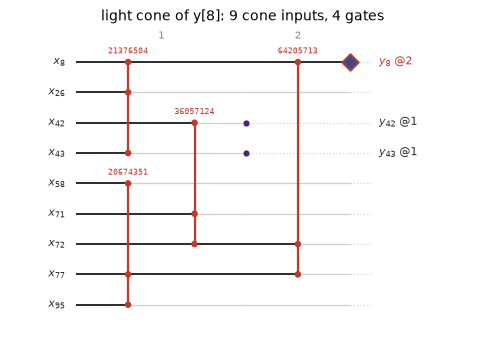

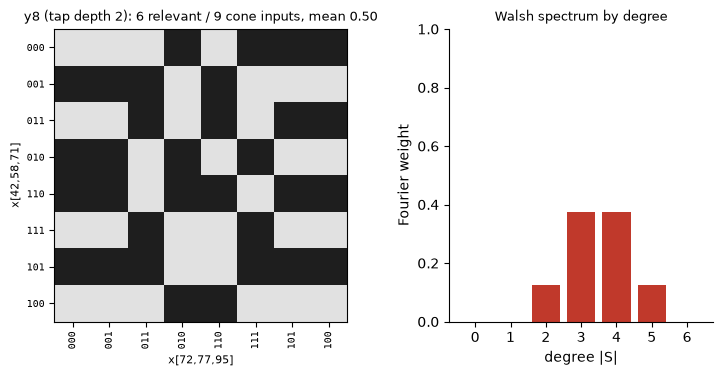

In [8]:
cone_sizes = cv.supports(c100).sum(axis=1)
w = int(np.flatnonzero((c100.out_depths == 2) & (cone_sizes >= 7))[0])
print(f"wire {w}: tap depth {c100.out_depths[w]}, cone inputs {cv.cone_inputs(c100, w)}")
cv.draw_circuit(c100, highlight=w, compact=True, show_tables=True)
cv.plot_function(c100, w);

The default 256-wire, depth-32 circuit. Influences are Monte Carlo estimates here (`n_samples` inputs, one bit flip per input wire), so "functional support" is a lower bound. Nearly every output past depth ~12 sits at total influence n/2, which is what a random function gives.

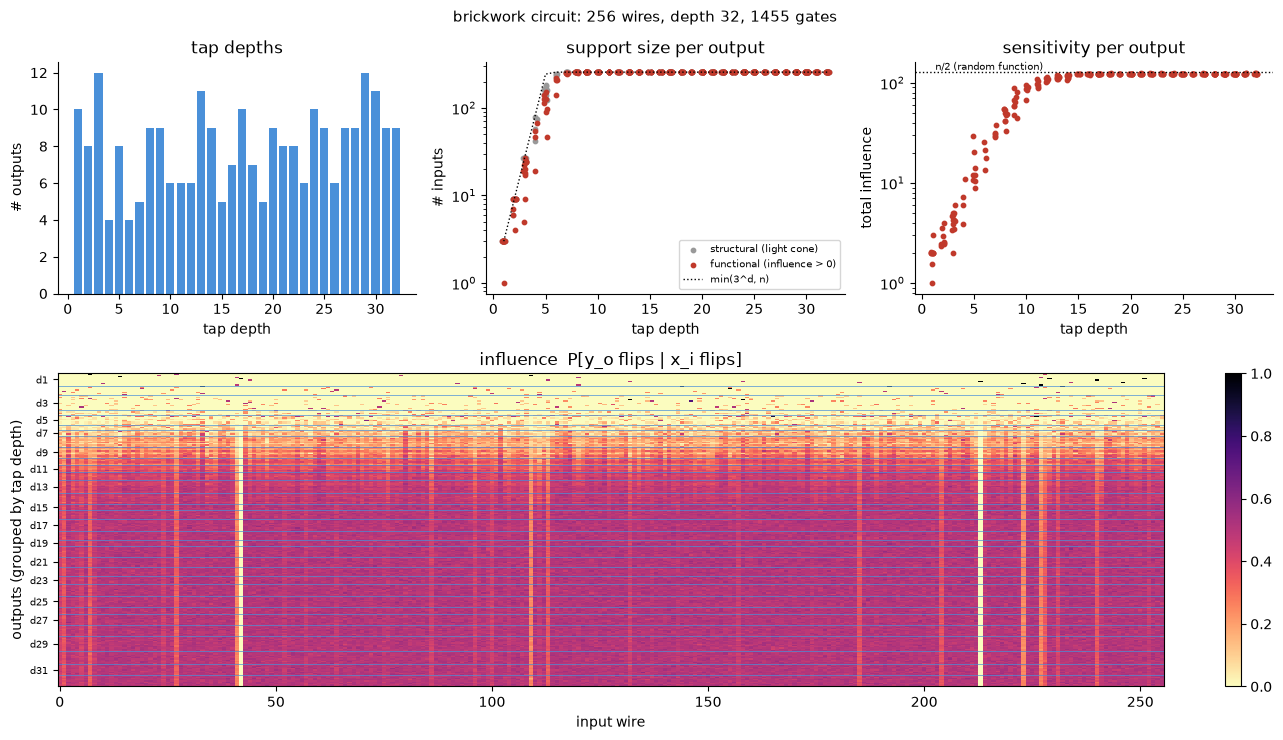

In [9]:
c256 = sample_circuit(np.random.default_rng(0), 256, 32)
inf256 = cv.influence(c256, n_samples=512)
cv.plot_summary(c256, inf=inf256);

**A sanity check the plot turns up:** a few input columns are almost blank. Each of these inputs affects exactly one output, tapped at depth 1. Its layer-1 gate carries a flip of that input bit onto a single output bit, and that wire freezes immediately, so none of the deep outputs can see this input.

In [10]:
total = inf256.sum(axis=0)
for i in np.flatnonzero(total < 2):
    hit = np.flatnonzero(inf256[:, i] > 0)
    print(f"input {i}: total influence {total[i]:.2f}, reaches outputs {hit} "
          f"(tap depths {c256.out_depths[hit]})")

input 42: total influence 1.00, reaches outputs [42] (tap depths [1])
input 213: total influence 1.00, reaches outputs [158] (tap depths [1])


## Tree circuits

Here tapped nodes are filled and colored by supervision gap, and untapped nodes are hollow. A small tree first, then the `tree_taps.ipynb` tree (2187 leaves, depth 7) at q=0.1: the whole tree, then one depth-4 subtree.

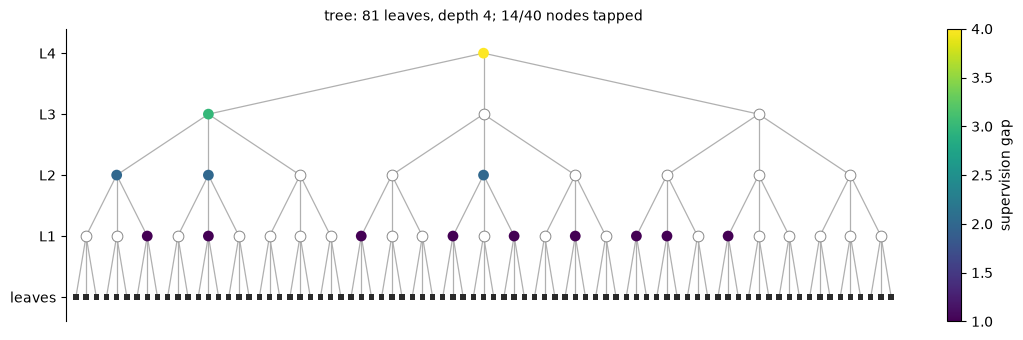

In [11]:
t81 = sample_tree_circuit(np.random.default_rng(0), 81, 4)
cv.draw_tree(t81, tapped=np.random.default_rng(1).random(t81.n_interior) < 0.4);

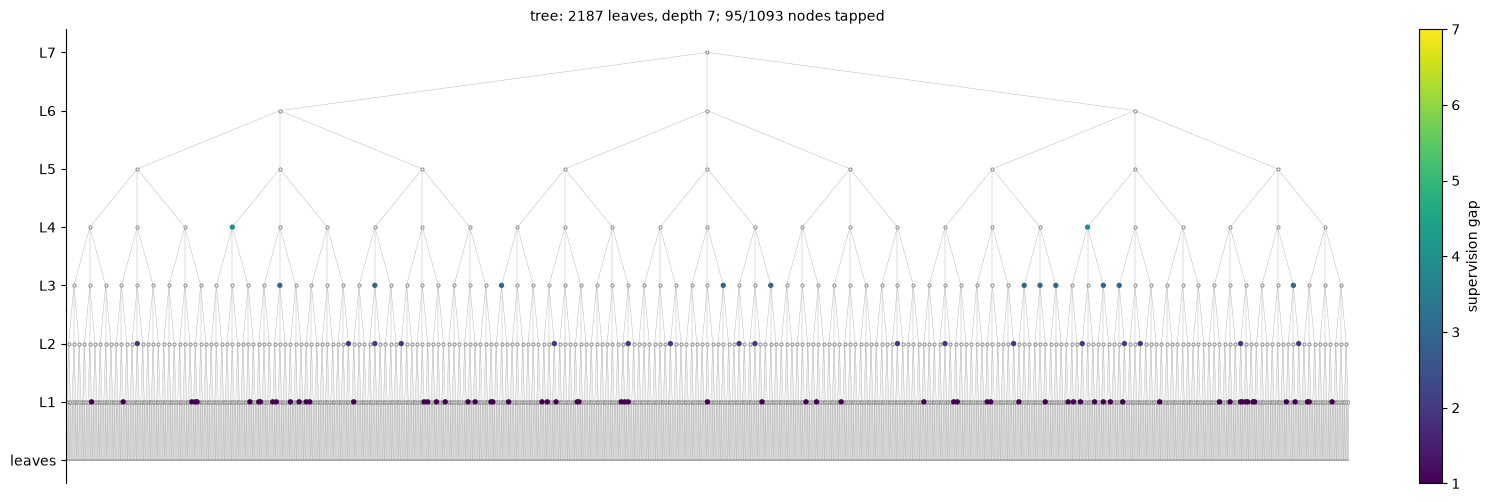

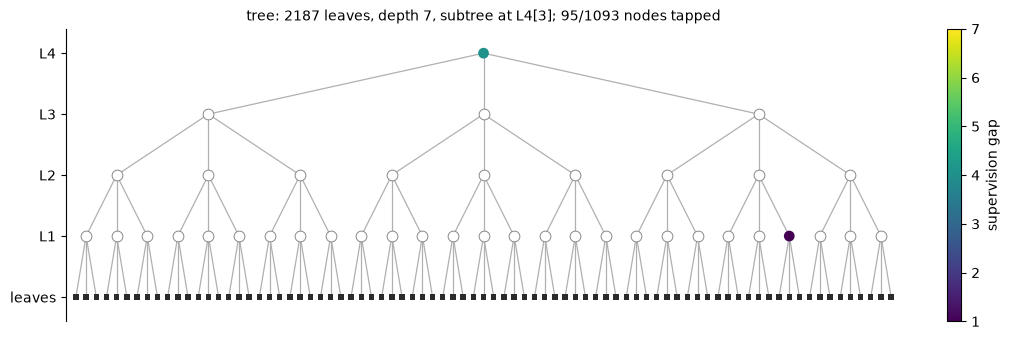

In [12]:
t7 = sample_tree_circuit(np.random.default_rng(0), 2187, 7)
tap = np.random.default_rng([1000, 100]).random(t7.n_interior) < 0.1   # tree_taps q=0.1
cv.draw_tree(t7, tap)
cv.draw_tree(t7, tap, subtree=(4, 3));

## Saving figures

Every function takes `ax=` (or `fig=` for `plot_summary`), so panels can be composed:

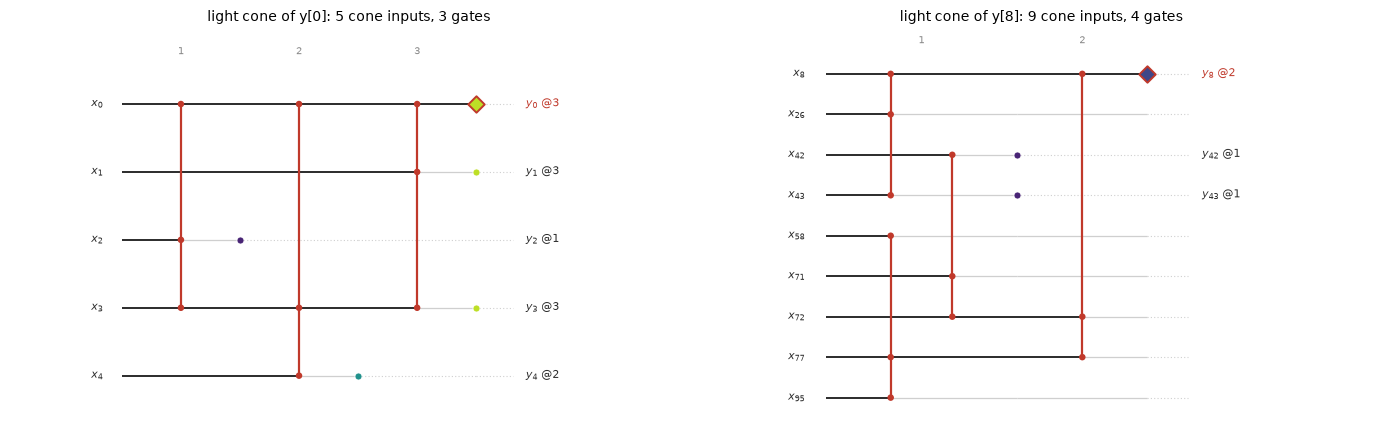

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
cv.draw_circuit(tiny, highlight=0, ax=axes[0])
cv.draw_circuit(c100, highlight=w, compact=True, ax=axes[1])
fig.tight_layout()
# fig.savefig("figs/light_cones.png", dpi=200, bbox_inches="tight")